In [1]:
pip install cdsapi xarray pandas netCDF4 matplotlib


   ---------------------------------------- 0/3 [multiurl]
   ------------- -------------------------- 1/3 [ecmwf-datastores-client]
   ---------------------------------------- 3/3 [cdsapi]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

In [2]:
import xarray as xr

# 1. Laad beide bestanden in
ds_instant = xr.open_dataset('data_stream-oper_stepType-instant.nc')
ds_accum = xr.open_dataset('data_stream-oper_stepType-accum.nc')

# 2. Voeg ze samen tot één dataset
# xarray koppelt ze automatisch op basis van tijd, latitude en longitude
ds_combined = xr.merge([ds_instant, ds_accum])

# 3. Bekijk het resultaat
print(ds_combined)

# Nu kun je door naar de DataFrame stap:
df = ds_combined.to_dataframe().reset_index()

C:\Users\qsoerohardjo\AppData\Local\Temp\ipykernel_4272\1101167389.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ds_instant, ds_accum])
C:\Users\qsoerohardjo\AppData\Local\Temp\ipykernel_4272\1101167389.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ds_instant, ds_accum])


<xarray.Dataset> Size: 460MB
Dimensions:     (valid_time: 2160, latitude: 81, longitude: 73)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 17kB 2000-06-01 ... 2002-06-30T23...
  * latitude    (latitude) float64 648B 15.0 14.75 14.5 ... -4.5 -4.75 -5.0
  * longitude   (longitude) float64 584B 33.0 33.25 33.5 ... 50.5 50.75 51.0
    expver      (valid_time) <U4 35kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    u10         (valid_time, latitude, longitude) float32 51MB ...
    v10         (valid_time, latitude, longitude) float32 51MB ...
    d2m         (valid_time, latitude, longitude) float32 51MB ...
    t2m         (valid_time, latitude, longitude) float32 51MB ...
    msl         (valid_time, latitude, longitude) float32 51MB ...
    swvl1       (valid_time, latitude, longitude) float32 51MB ...
    tp          (valid_time, latitude, longitude) float32 51MB ...
    e           (valid_time, latitude, longitude) float32 51MB ...
    

In [3]:
df

,valid_time,latitude,longitude,u10,v10,d2m,t2m,msl,swvl1,number,expver,tp,e,ro
0,2000-06-01 00:00:00,15.0,33.00,0.506241,4.229965,289.776855,304.123779,100593.3125,0.185074,0,0001,0.000000,-3.958354e-06,0.0
1,2000-06-01 00:00:00,15.0,33.25,0.513077,3.790512,290.270996,303.905029,100600.0625,0.193344,0,0001,0.000000,-1.033605e-05,0.0
2,2000-06-01 00:00:00,15.0,33.50,0.538467,3.432114,290.360840,303.602295,100611.5625,0.200699,0,0001,0.000000,-7.695053e-07,0.0
3,2000-06-01 00:00:00,15.0,33.75,0.746475,2.830551,290.604980,303.049561,100613.3125,0.205414,0,0001,0.000000,-4.703412e-06,0.0
4,2000-06-01 00:00:00,15.0,34.00,1.061905,2.838364,290.622559,302.928467,100619.8125,0.183578,0,0001,0.000000,-4.416797e-07,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12772075,2002-06-30 23:00:00,-5.0,50.00,-0.590439,7.229660,295.480713,298.296875,101446.0625,0.000010,0,0001,0.000064,-1.811383e-04,0.0
12772076,2002-06-30 23:00:00,-5.0,50.25,-0.472275,7.230637,295.562744,298.300781,101436.8125,0.000010,0,0001,0.000068,-1.776216e-04,0.0
12772077,2002-06-30 23:00:00,-5.0,50.50,-0.412704,7.267746,295.638916,298.318359,101427.8125,0.000010,0,0001,0.000099,-1.789925e-04,0.0
12772078,2002-06-30 23:00:00,-5.0,50.75,-0.476181,7.333176,295.635010,298.408203,101419.8125,0.000010,0,0001,0.000093,-1.880822e-04,0.0


In [4]:
# Kelvin naar Celsius
df['t2m'] = df['t2m'] - 273.15
df['d2m'] = df['d2m'] - 273.15

# Meters naar millimeters (tp, e, ro)
# Let op: e (verdamping) is vaak negatief in ERA5, we maken het positief voor gemak
df['tp'] = df['tp'] * 1000
df['e'] = df['e'].abs() * 1000
df['ro'] = df['ro'] * 1000

In [5]:
df = df.sort_values(by=['latitude', 'longitude', 'valid_time']).reset_index(drop=True)

In [6]:
def fast_api(precip_array, decay=0.85):
    api = [0.0] * len(precip_array)
    for i in range(1, len(precip_array)):
        api[i] = (api[i-1] * decay) + precip_array[i]
    return api

# We groeperen per locatie en passen de API toe
df['api'] = df.groupby(['latitude', 'longitude'])['tp'].transform(lambda x: fast_api(x.values))

In [7]:
# Bepaal de drempelwaarde (bijv. 99e percentiel)
threshold = df['tp'].quantile(0.99)

# Maak de target: is de neerslag over 24 uur groter dan de drempel?
df['target_flood'] = df.groupby(['latitude', 'longitude'])['tp'].shift(-24)
df['target_flood'] = (df['target_flood'] > threshold).astype(int)

# Verwijder de laatste 24 uur per locatie (die hebben geen target)
df = df.dropna(subset=['target_flood'])

In [8]:
print(df['target_flood'].value_counts(normalize=True))

target_flood
0    0.990016
1    0.009984
Name: proportion, dtype: float64


In [16]:
# Groepeer per locatie om te voorkomen dat data van verschillende plekken mengt
grouped = df.groupby(['latitude', 'longitude'])

# 1. Regen van de afgelopen 6 uur (Trigger intensiteit)
df['tp_6h_sum'] = grouped['tp'].transform(lambda x: x.rolling(window=6).sum())

# 2. Regen van de afgelopen week (Bodemverzadiging)
# Omdat we uurlijkse data hebben: 7 dagen * 24 uur = 168
df['tp_7d_sum'] = grouped['tp'].transform(lambda x: x.rolling(window=168).sum())

# 3. Temperatuur trend (helpt bij verdamping/uitdroging)
df['t2m_24h_avg'] = grouped['t2m'].transform(lambda x: x.rolling(window=24).mean())

# Vergeet niet de NaN waardes te droppen die ontstaan aan het begin van de reeks
df = df.dropna()

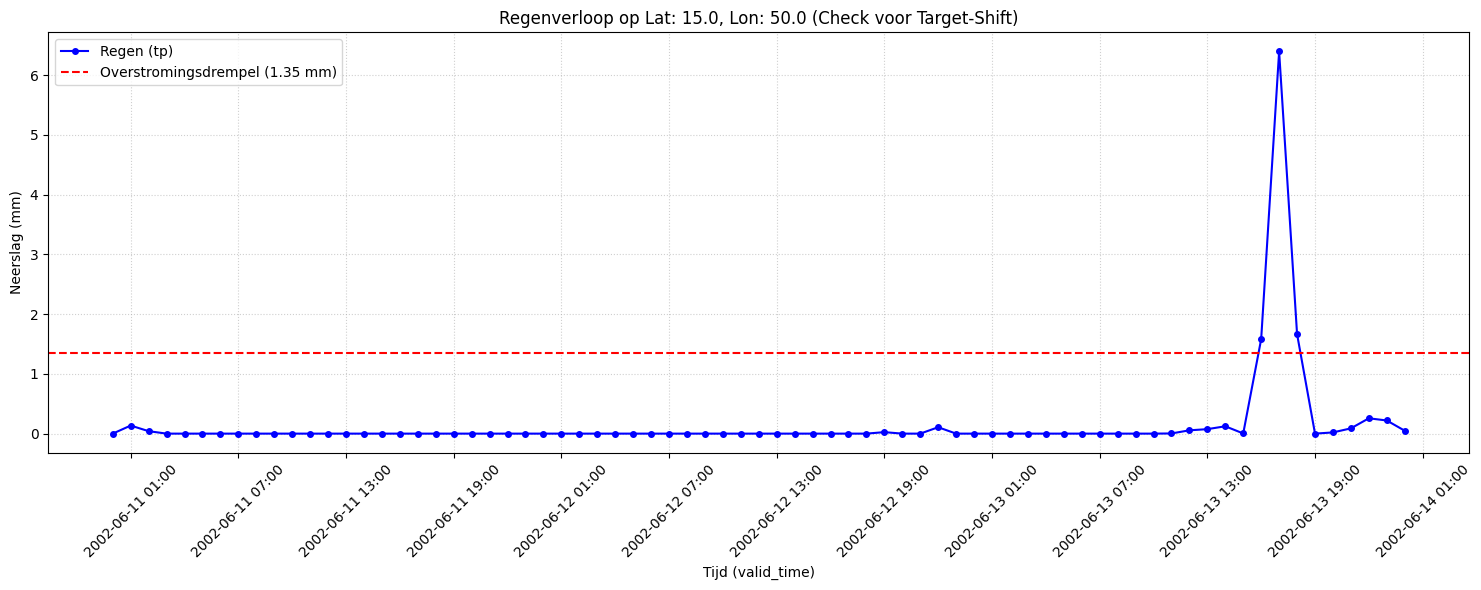

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Selecteer de data (pas lat/lon aan naar de rij die je onderzocht)
lat = 15.0
lon = 50.0
check = df[(df['latitude'] == lat) & (df['longitude'] == lon)]
check = check[(check['valid_time'] >= '2002-06-11') & (check['valid_time'] <= '2002-06-14')]

# 2. Maak de figuur breder (figsize=(15, 6))
plt.figure(figsize=(15, 6))

# 3. Plot de neerslag
plt.plot(check['valid_time'], check['tp'], label='Regen (tp)', color='blue', marker='o', markersize=4)

# 4. Voeg de drempelwaarde toe
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Overstromingsdrempel ({threshold:.2f} mm)')

# 5. X-as verbeteren: Rotatie en opmaak
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6)) # Toon elke 6 uur een label

# 6. Styling
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Tijd (valid_time)')
plt.ylabel('Neerslag (mm)')
plt.title(f"Regenverloop op Lat: {lat}, Lon: {lon} (Check voor Target-Shift)")
plt.legend()

plt.tight_layout() # Zorgt dat labels niet van de figuur afvallen
plt.show()

In [17]:
# 1. Splits de data in overstromingen en niet-overstromingen
df_floods = df[df['target_flood'] == 1]
df_no_floods = df[df['target_flood'] == 0]

# 2. Pak een subset van de normale dagen (bijv. 2x zoveel als de overstromingen)
df_no_floods_sample = df_no_floods.sample(n=len(df_floods) * 2, random_state=42)

# 3. Voeg ze weer samen tot een trainingsset
df_train_balanced = pd.concat([df_floods, df_no_floods_sample])

# 4. Schud de data door elkaar
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42)

print(f"Nieuwe dataset grootte: {len(df_train_balanced)} rijen")
print(df_train_balanced['target_flood'].value_counts(normalize=True))

Nieuwe dataset grootte: 356598 rijen
target_flood
0    0.666667
1    0.333333
Name: proportion, dtype: float64


In [18]:
# We kiezen de variabelen die wetenschappelijk relevant zijn
features = [
    'u10', 'v10', 'd2m', 't2m', 'msl', 'swvl1', 
    'tp', 'api', 'tp_6h_sum', 'tp_7d_sum', 't2m_24h_avg'
]

X = df_train_balanced[features]
y = df_train_balanced['target_flood']

In [19]:
# 1. Zorg dat de data eerst weer op tijd gesorteerd staat (belangrijk!)
df_train_balanced = df_train_balanced.sort_values('valid_time')

# 2. Bepaal een datum als breekpunt (bijv. de laatste 6 maanden als test)
split_date = pd.to_datetime('2002-01-01')

# 3. Splits op basis van tijd
train_indices = df_train_balanced['valid_time'] < split_date
test_indices = df_train_balanced['valid_time'] >= split_date

X_train = df_train_balanced.loc[train_indices, features]
y_train = df_train_balanced.loc[train_indices, 'target_flood']

X_test = df_train_balanced.loc[test_indices, features]
y_test = df_train_balanced.loc[test_indices, 'target_flood']

print(f"Train set: {X_train.shape[0]} rijen (tot {split_date})")
print(f"Test set: {X_test.shape[0]} rijen (vanaf {split_date})")

Train set: 231742 rijen (tot 2002-01-01 00:00:00)
Test set: 124856 rijen (vanaf 2002-01-01 00:00:00)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# We maken een pipeline: eerst schalen, dan de Logistische Regressie
# 'class_weight=balanced' is handig als je dataset nog steeds een beetje scheef is
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train het model op de trainingset
pipeline_lr.fit(X_train, y_train)

print("Model succesvol getraind!")

Model succesvol getraind!



--- Logistische Regressie Evaluatie Rapport ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     85803
           1       0.76      0.78      0.77     39053

    accuracy                           0.85    124856
   macro avg       0.83      0.83      0.83    124856
weighted avg       0.85      0.85      0.85    124856

ROC-AUC Score: 0.9064


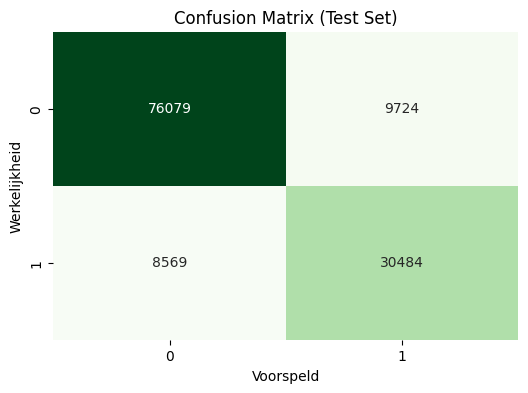

In [21]:
# Voorspellingen doen
y_pred = pipeline_lr.predict(X_test)
y_probs = pipeline_lr.predict_proba(X_test)[:, 1] # Kansen voor de AUC-ROC score

# Rapport uitdraaien
print("\n--- Logistische Regressie Evaluatie Rapport ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# Confusion Matrix visualisatie
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijkheid')
plt.show()

C:\Users\qsoerohardjo\AppData\Local\Temp\ipykernel_4272\4272259784.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')


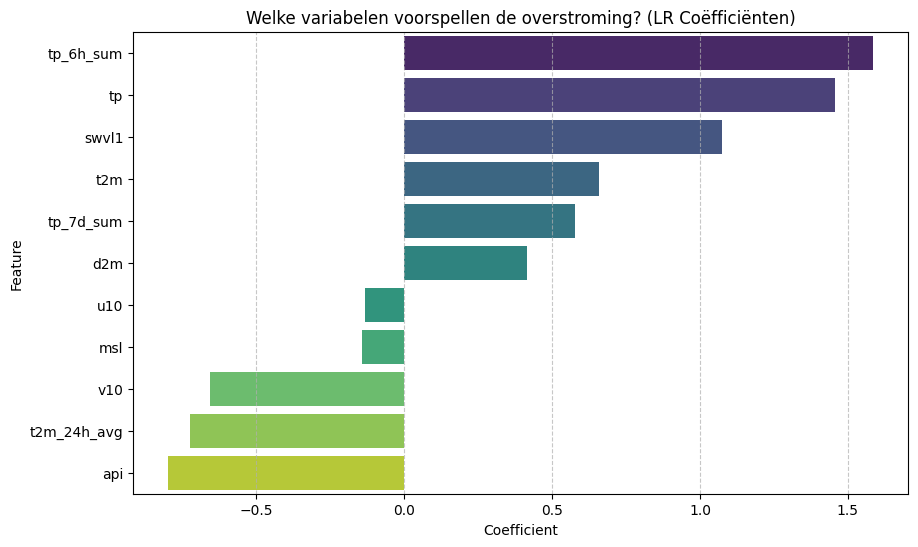

In [22]:
# Haal de coëfficiënten uit de getrainde LR
coefs = pipeline_lr.named_steps['lr'].coef_[0]
importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
importance_df = importance_df.sort_values(by='Coefficient', ascending=False)

# Plotten
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')
plt.title('Welke variabelen voorspellen de overstroming? (LR Coëfficiënten)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [23]:
from xgboost import XGBClassifier

# Initialiseer model
model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)

# Train op je bestaande X_train, y_train
model_xgb.fit(X_train, y_train)

# Evalueer
y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     85803
           1       0.81      0.78      0.80     39053

    accuracy                           0.87    124856
   macro avg       0.86      0.85      0.85    124856
weighted avg       0.87      0.87      0.87    124856



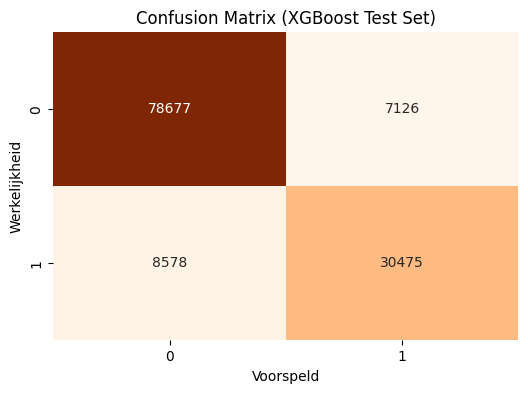

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix (XGBoost Test Set)')
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijkheid')
plt.show()

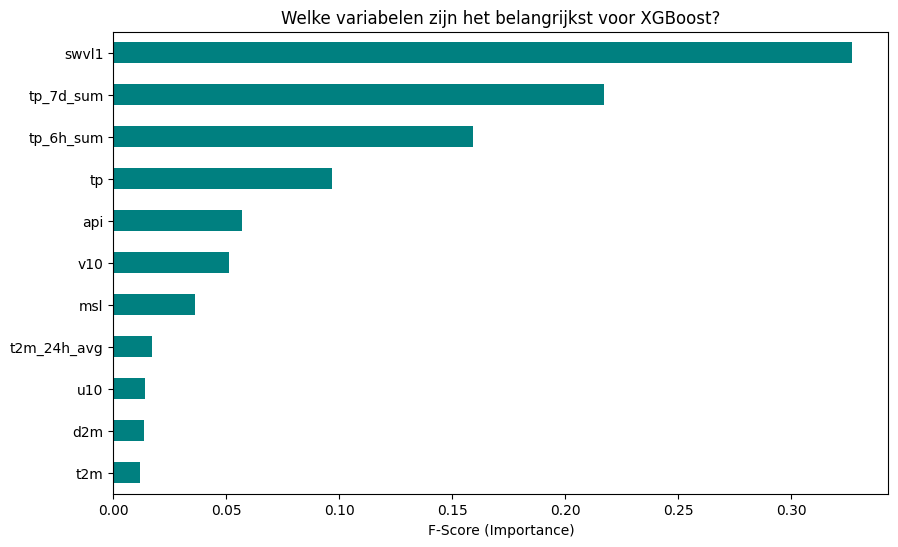

In [25]:
# Haal feature importances op
importance_xgb = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance_xgb.plot(kind='barh', color='teal')
plt.title('Welke variabelen zijn het belangrijkst voor XGBoost?')
plt.xlabel('F-Score (Importance)')
plt.show()